In [89]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams.update({
    # figure
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "savefig.dpi": 120,
    "savefig.bbox": "tight",

    # remove chart junk
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,

    # fonts / sizes
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",     # left-aligned titles read cleaner
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # lighten tick marks and label colour
    "xtick.color": "#444",
    "ytick.color": "#444",
    "axes.labelcolor": "#333",
    "axes.edgecolor": "#888",

    # spacing
    "axes.titlepad": 14,
    "axes.labelpad": 8,
})

PRIMARY = "#7048a8"                    # purple, for single-colour charts
SEQ_CMAP = "Purples"                   # for heatmaps

# EDA

In [90]:
# Load dataset
df = pd.read_csv('/content/acnc_register.csv')
df.head(5)

/tmp/ipykernel_2770/82683112.py:2: DtypeWarning: Columns (7,10,67) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/acnc_register.csv')


,_id,ABN,Charity_Legal_Name,Other_Organisation_Names,Address_Type,Address_Line_1,Address_Line_2,Address_Line_3,Town_City,State,...,Pre_Post_Release_Offenders,Rural_Regional_Remote_Communities,Unemployed_Person,Veterans_or_their_families,Victims_of_crime,Victims_of_Disasters,Youth,animals,environment,other_gender_identities
0,1,9.783047e+10,The Dale Family Foundation,NaN,Business,L 15 216 St Georges Tce,NaN,NaN,Perth,WA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,9.017506e+10,The SJD Homes Foundation,NaN,Business,433 Princes Hwy,NaN,NaN,Officer,VIC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,7.531376e+10,NORTH WEST REGIONAL LANDCARERS INC,NaN,Business,Po Box 3122,NaN,NaN,West Tamworth,NSW,...,NaN,Y,NaN,NaN,NaN,NaN,Y,Y,Y,Y
3,4,5.428176e+10,Catholic Cemeteries & Crematoria Trust,NaN,Business,L 2 11 Murray Rose Ave,NaN,NaN,Sydney Olympic Park,NSW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,6.324743e+10,HOPE ARABIC CHURCH INCORPORATED,"Hope Arabic Church - South Australia, كنيسة ال...",Business,614 Burbridge Rd,NaN,NaN,West Beach,SA,...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN


In [91]:
df.shape

(66232, 70)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66232 entries, 0 to 66231
Data columns (total 70 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   _id                                                             66232 non-null  int64  
 1   ABN                                                             65629 non-null  float64
 2   Charity_Legal_Name                                              66011 non-null  object 
 3   Other_Organisation_Names                                        7007 non-null   object 
 4   Address_Type                                                    66232 non-null  object 
 5   Address_Line_1                                                  59309 non-null  object 
 6   Address_Line_2                                                  5792 non-null   object 
 7   Address_Line_3                                   

In [93]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
_id,66232.0,3.311650e+04,1.911968e+04,1.000000e+00,1.655875e+04,3.311650e+04,4.967425e+04,6.623200e+04
ABN,65629.0,5.532398e+10,2.566669e+10,1.100005e+10,3.311223e+10,5.503932e+10,7.761481e+10,9.999461e+10
Number_of_Responsible_Persons,66232.0,5.247554e+00,3.160480e+00,0.000000e+00,3.000000e+00,5.000000e+00,7.000000e+00,5.900000e+01


## Data Cleaning and Handling Inconsistencies

In [94]:
# Quite a lot of null values
# This is to be expected because each NGO does not have to be associated with all possible subtypes and beneficiaries
df.isnull().sum()

,0
_id,0
ABN,603
Charity_Legal_Name,221
Other_Organisation_Names,59225
Address_Type,0
...,...
Victims_of_Disasters,60192
Youth,36937
animals,63307
environment,62265


In [95]:
# We first start by identifying subtype  & benefactor columns
subtype_keywords = df.columns[27:41].tolist()
benefactor_keywords = df.columns[41:70].tolist()

subtype_cols = []
benefactor_cols = []

for col in df.columns:
  for key in subtype_keywords:
      if key in col:
          subtype_cols.append(col)

for col in df.columns:
  if col not in subtype_cols:
    for key in benefactor_keywords:
        if key in col:
            benefactor_cols.append(col)

# An NGO satisfies the not null condition if it has at least one 'Y' (non-null) in both categories
has_subtype = df[subtype_cols].notna().any(axis=1)
has_benefactor = df[benefactor_cols].notna().any(axis=1)
satisfies_condition = has_subtype & has_benefactor

# Filter the dataframe to remove NGOs that break this condition
df_filtered = df[satisfies_condition].reset_index(drop=True)

num_satisfying = len(df_filtered)
total = len(df)
print(f"NGOs satisfying the condition: {num_satisfying} out of {total} ({(num_satisfying/total)*100:.2f}%)")
print(f"Removed {total - num_satisfying} NGOs that broke the condition.")

NGOs satisfying the condition: 60014 out of 66232 (90.61%)
Removed 6218 NGOs that broke the condition.


In [96]:
# 0 duplicates
df_filtered.duplicated().sum()

np.int64(0)

In [97]:
# % of missing values in each column
(df_filtered.isnull().sum()/(len(df)))*100

,0
_id,0.000000
ABN,0.584310
Charity_Legal_Name,0.117768
Other_Organisation_Names,80.625679
Address_Type,0.000000
...,...
Victims_of_Disasters,81.924145
Youth,48.769477
animals,86.577485
environment,85.150682


In [98]:
# Drop unnecesaary columns
indicies_to_drop = np.r_[1, 3:8, 10, 12:15, 17]
df_new = df_filtered.drop(df_filtered.columns[indicies_to_drop], axis = 1)
df_new.head(5)

,_id,Charity_Legal_Name,Town_City,State,Country,Charity_Size,Number_of_Responsible_Persons,Operates_in_ACT,Operates_in_NSW,Operates_in_NT,...,Pre_Post_Release_Offenders,Rural_Regional_Remote_Communities,Unemployed_Person,Veterans_or_their_families,Victims_of_crime,Victims_of_Disasters,Youth,animals,environment,other_gender_identities
0,2,The SJD Homes Foundation,Officer,VIC,Australia,Small,7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,NORTH WEST REGIONAL LANDCARERS INC,West Tamworth,NSW,Australia,Medium,5,NaN,Y,NaN,...,NaN,Y,NaN,NaN,NaN,NaN,Y,Y,Y,Y
2,4,Catholic Cemeteries & Crematoria Trust,Sydney Olympic Park,NSW,Australia,Large,5,NaN,Y,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,HOPE ARABIC CHURCH INCORPORATED,West Beach,SA,Australia,Small,5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN
4,6,Frederick Miller Community Garden,Semaphore Park,SA,Australia,NaN,3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,Y


In [99]:
# Remove all charities not in Australia
df_new = df_new[df_new['Country'] == 'Australia']
df_new.head(5)

,_id,Charity_Legal_Name,Town_City,State,Country,Charity_Size,Number_of_Responsible_Persons,Operates_in_ACT,Operates_in_NSW,Operates_in_NT,...,Pre_Post_Release_Offenders,Rural_Regional_Remote_Communities,Unemployed_Person,Veterans_or_their_families,Victims_of_crime,Victims_of_Disasters,Youth,animals,environment,other_gender_identities
0,2,The SJD Homes Foundation,Officer,VIC,Australia,Small,7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,NORTH WEST REGIONAL LANDCARERS INC,West Tamworth,NSW,Australia,Medium,5,NaN,Y,NaN,...,NaN,Y,NaN,NaN,NaN,NaN,Y,Y,Y,Y
2,4,Catholic Cemeteries & Crematoria Trust,Sydney Olympic Park,NSW,Australia,Large,5,NaN,Y,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,HOPE ARABIC CHURCH INCORPORATED,West Beach,SA,Australia,Small,5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN
4,6,Frederick Miller Community Garden,Semaphore Park,SA,Australia,NaN,3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,Y


In [100]:
# Remove all charities that are listed to not be operating in either one of the 8 states
state_operations = df_new.columns[7:15].tolist()
print(state_operations)

state_operations_cols = []

for col in df_new.columns:
  for key in state_operations:
      if key in col:
          state_operations_cols.append(col)

# An NGO satisfies the not null condition if it has at least one 'Y' (non-null) in any given states
operates_in_aus_state = df[state_operations_cols].notna().any(axis=1)
print(operates_in_aus_state)

# Filter the dataframe to remove NGOs that break this condition
df_new_filtered = df_new[operates_in_aus_state].reset_index(drop=True)

num_satisfying = len(df_new_filtered)
total = len(df_new)
print(f"NGOs satisfying the condition: {num_satisfying} out of {total} ({(num_satisfying/total)*100:.2f}%)")
print(f"Removed {total - num_satisfying} NGOs that broke the condition.")

['Operates_in_ACT', 'Operates_in_NSW', 'Operates_in_NT', 'Operates_in_QLD', 'Operates_in_SA', 'Operates_in_TAS', 'Operates_in_VIC', 'Operates_in_WA']
0        False
1         True
2         True
3         True
4         True
         ...  
66227     True
66228     True
66229     True
66230     True
66231     True
Length: 66232, dtype: bool
NGOs satisfying the condition: 38432 out of 50127 (76.67%)
Removed 11695 NGOs that broke the condition.


/tmp/ipykernel_2770/1604147035.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_new_filtered = df_new[operates_in_aus_state].reset_index(drop=True)


In [101]:
df_new_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38432 entries, 0 to 38431
Data columns (total 59 columns):
 #   Column                                                          Non-Null Count  Dtype 
---  ------                                                          --------------  ----- 
 0   _id                                                             38432 non-null  int64 
 1   Charity_Legal_Name                                              38430 non-null  object
 2   Town_City                                                       36635 non-null  object
 3   State                                                           36608 non-null  object
 4   Country                                                         38432 non-null  object
 5   Charity_Size                                                    34102 non-null  object
 6   Number_of_Responsible_Persons                                   38432 non-null  int64 
 7   Operates_in_ACT                                           

In [102]:
# Convert data types to integers for one-hot encoding
df_new_filtered[state_operations_cols] = (df_new_filtered[state_operations_cols] == 'Y').astype(int)
df_new_filtered[benefactor_cols] = (df_new_filtered[benefactor_cols] == 'Y').astype(int)
df_new_filtered[subtype_cols] = (df_new_filtered[subtype_cols] == 'Y').astype(int)
df_new_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38432 entries, 0 to 38431
Data columns (total 59 columns):
 #   Column                                                          Non-Null Count  Dtype 
---  ------                                                          --------------  ----- 
 0   _id                                                             38432 non-null  int64 
 1   Charity_Legal_Name                                              38430 non-null  object
 2   Town_City                                                       36635 non-null  object
 3   State                                                           36608 non-null  object
 4   Country                                                         38432 non-null  object
 5   Charity_Size                                                    34102 non-null  object
 6   Number_of_Responsible_Persons                                   38432 non-null  int64 
 7   Operates_in_ACT                                           

In [103]:
# Filter to one subtype's charities
subtype = "Advancing_Culture"

# Boolean mask: True for charities registered with this subtype
mask = df_new_filtered[subtype] == 1
culture_charities = df_new_filtered[mask]

print(f"Number of charities registered with {subtype}: {mask.sum()}"
      f"({mask.mean()*100:.1f}% of all charities)")

Number of charities registered with Advancing_Culture: 4044(10.5% of all charities)


In [104]:
# For this charity, find what fraction serve each beneficiary.

# For the filtered charities, the mean of each 0/1 beneficiary column = the proportion of those charities serving that beneficiary.
within = culture_charities[benefactor_cols].mean().sort_values(ascending=False)
within

print("Top Beneficiaries served by Advancing_Culture charities:")
print((within * 100).round(1))

Top Beneficiaries served by Advancing_Culture charities:
Adults                                 65.6
Youth                                  63.9
Aged_Persons                           58.2
Families                               52.8
General_Community_in_Australia         52.3
Children                               47.7
Females                                43.9
Ethnic_Groups                          43.8
Rural_Regional_Remote_Communities      42.0
Males                                  41.7
Aboriginal_or_TSI                      39.3
Financially_Disadvantaged              31.7
People_with_Disabilities               26.4
Early_Childhood                        24.6
Unemployed_Person                      20.6
other_gender_identities                15.2
People_at_risk_of_homelessness         14.5
Migrants_Refugees_or_Asylum_Seekers    12.7
People_with_Chronic_Illness            12.4
Other_Charities                        11.2
Veterans_or_their_families             10.7
Victims_of_crime   

####Comparing to the baseline

Suppose 80% of culture charities serve 'Adults.'
To know whether this proportion is uniquely characteristic of Culture charities, we need to compare it to the baseline rate
So we compare the within-subtype rate and the overall baseline rate


In [105]:
# Baseline: proportion of ALL charities serving each beneficiary
baseline = df_new_filtered[benefactor_cols].mean().sort_values(ascending=False)
print("Baseline:")
print((baseline * 100).round(1))


Baseline:
Youth                                  49.8
Adults                                 49.3
Families                               47.4
Aged_Persons                           44.6
Children                               43.5
General_Community_in_Australia         40.2
Females                                37.8
Males                                  35.6
Financially_Disadvantaged              33.2
Rural_Regional_Remote_Communities      30.9
Ethnic_Groups                          30.4
Early_Childhood                        30.1
People_with_Disabilities               27.4
Aboriginal_or_TSI                      26.6
People_at_risk_of_homelessness         19.8
Unemployed_Person                      19.3
People_with_Chronic_Illness            16.8
Victims_of_crime                       11.2
Other_Charities                        10.8
Veterans_or_their_families             10.8
Victims_of_Disasters                   10.0
Communities_Overseas                    9.4
other_gender_identitie

In [106]:
# Lift: how much more (or less) this subtype serves each beneficiary vs baseline.
lift = (within - baseline ).sort_values(ascending=False)

comparison = pd.DataFrame({
    "within_subtype_%": (within * 100).round(1),
    "baseline %": (baseline * 100).round(1),
    "lift_pts": (lift * 100).round(1),
}).sort_values(by="lift_pts", ascending=False)

print(f"\n{subtype}: beneficiaries most OVER-served vs National Baseline")
print(comparison.head(10))
print(f"\n{subtype}: beneficiaries most UNDER-served vs National Baseline")
print(comparison.tail(10))


Advancing_Culture: beneficiaries most OVER-served vs National Baseline
                                   within_subtype_%  baseline %  lift_pts
Adults                                         65.6        49.3      16.4
Youth                                          63.9        49.8      14.1
Aged_Persons                                   58.2        44.6      13.6
Ethnic_Groups                                  43.8        30.4      13.4
Aboriginal_or_TSI                              39.3        26.6      12.7
General_Community_in_Australia                 52.3        40.2      12.1
Rural_Regional_Remote_Communities              42.0        30.9      11.1
other_gender_identities                        15.2         8.3       6.9
Females                                        43.9        37.8       6.2
Males                                          41.7        35.6       6.1

Advancing_Culture: beneficiaries most UNDER-served vs National Baseline
                                within_su

In [107]:
def beneficaries_subtype(df, subtype, beneficiaries, top_n=8):
  """Return the beneficiaries this subtype over/under serves vs the baseline"""
  mask = df[subtype] == 1

  within = df[mask][beneficiaries].mean()
  baseline = df[beneficiaries].mean()
  lift = (within - baseline).sort_values(ascending=False)

  return (lift * 100).round(1)

In [108]:
for s in subtype_cols:
  print(f"\n=== {s}: top 8 under-served beneficiaries (lift in pts) ===")
  print(beneficaries_subtype(df_new_filtered, s, benefactor_cols).tail(8).sort_values())


=== PBI: top 8 under-served beneficiaries (lift in pts) ===
General_Community_in_Australia   -13.7
environment                       -2.4
animals                           -2.1
Other_Charities                   -1.0
LGBTIQA+                          -0.1
Other_Beneficiaries               -0.0
Early_Childhood                    0.6
Children                           1.6
dtype: float64

=== HPC: top 8 under-served beneficiaries (lift in pts) ===
Children                         -5.1
environment                      -4.3
animals                          -3.3
Financially_Disadvantaged        -3.1
People_at_risk_of_homelessness   -3.1
Unemployed_Person                -2.3
Early_Childhood                  -1.3
Communities_Overseas             -0.9
dtype: float64

=== Preventing_or_relieving_suffering_of_animals: top 8 under-served beneficiaries (lift in pts) ===
Children          -27.4
Youth             -26.9
Early_Childhood   -19.8
Adults            -18.4
Aged_Persons      -17.2
Ethnic_Gro

In [109]:
for s in subtype_cols:
  print(f"\n=== {s}: top 8 over-served beneficiaries (lift in pts) ===")
  print(beneficaries_subtype(df_new_filtered, s, benefactor_cols).head(8))


=== PBI: top 8 over-served beneficiaries (lift in pts) ===
Financially_Disadvantaged         23.9
People_with_Disabilities          23.4
People_at_risk_of_homelessness    21.7
Aboriginal_or_TSI                 16.5
Unemployed_Person                 14.7
Victims_of_crime                  11.9
Females                           11.8
People_with_Chronic_Illness       11.3
dtype: float64

=== HPC: top 8 over-served beneficiaries (lift in pts) ===
People_with_Chronic_Illness          29.2
Adults                               14.3
Rural_Regional_Remote_Communities    10.1
Males                                10.1
Aged_Persons                         10.0
People_with_Disabilities              9.1
Females                               9.0
Aboriginal_or_TSI                     6.6
dtype: float64

=== Preventing_or_relieving_suffering_of_animals: top 8 over-served beneficiaries (lift in pts) ===
animals                           75.9
environment                       25.0
Other_Charities        

### How is charity size associated with each subtype?




In [110]:
from scipy import stats as scs
import statsmodels.stats.multitest as smm

In [111]:
# Contingency table for each subtype to see the distribution of charity size
results = []
for s in subtype_cols:
  contingency_table = pd.crosstab(df_new_filtered['Charity_Size'], df_new_filtered[s])

  # we run chi-square test when we want to find out the relationship between two categorical variables
  res = scs.chi2_contingency(contingency_table)

  # calculate Cramer's V
  total_num_observations = contingency_table.sum().sum()
  min_dim = min(contingency_table.shape) - 1
  cramer_v = np.sqrt((res.statistic / total_num_observations) / min_dim)

  results.append({
      "subtype": s,
      "chi2"  : res.statistic,
      "raw_p": res.pvalue,
      "cramers_v": cramer_v,
  })

print(len(results), "rows collected")           # confirm 14 before proceeding
results_df = pd.DataFrame(results)
print(results_df.columns.tolist())              # confirm 'subtype' is there

# Benjamini-Hochberg across 14 tests
# Alpha sets the desired False Discovery Rate threshold
reject, p_adjusted, _, _ = smm.multipletests(
    results_df["raw_p"],
    alpha=0.05,
    method="fdr_bh",     # fdr_bh = Benjamini-Hochberg
)
results_df["p_bh"] = p_adjusted
results_df["sig_after_bh"] = reject

# sort by EFFECT SIZE, not p-value ---
final = results_df.sort_values("cramers_v", ascending=False)
print(final[["subtype", "cramers_v", "raw_p", "p_bh", "sig_after_bh"]].to_string(index=False))

# --- Summary stats worth stating in the writeup ---
print(f"\nSignificant before correction: {(results_df['raw_p'] < 0.05).sum()} / 14")
print(f"Significant after BH:          {results_df['sig_after_bh'].sum()} / 14")
print(f"Subtypes with Cramer's V > 0.10 (practically meaningful): "
      f"{(results_df['cramers_v'] > 0.10).sum()}")


14 rows collected
['subtype', 'chi2', 'raw_p', 'cramers_v']
                                                       subtype  cramers_v         raw_p          p_bh  sig_after_bh
                                                           PBI   0.272974  0.000000e+00  0.000000e+00          True
                                            Advancing_Religion   0.169376 3.626230e-213 2.538361e-212          True
                            Advancing_social_or_public_welfare   0.075039  2.008897e-42  9.374852e-42          True
                                           Advancing_Education   0.066852  8.025927e-34  2.809074e-33          True
                          Promoting_or_protecting_human_rights   0.055838  8.151070e-24  2.282300e-23          True
Purposes_beneficial_to_ther_general_public_and_other_analogous   0.052119  7.674531e-21  1.790724e-20          True
                  Preventing_or_relieving_suffering_of_animals   0.050872  6.853464e-20  1.370693e-19          True
            

saved


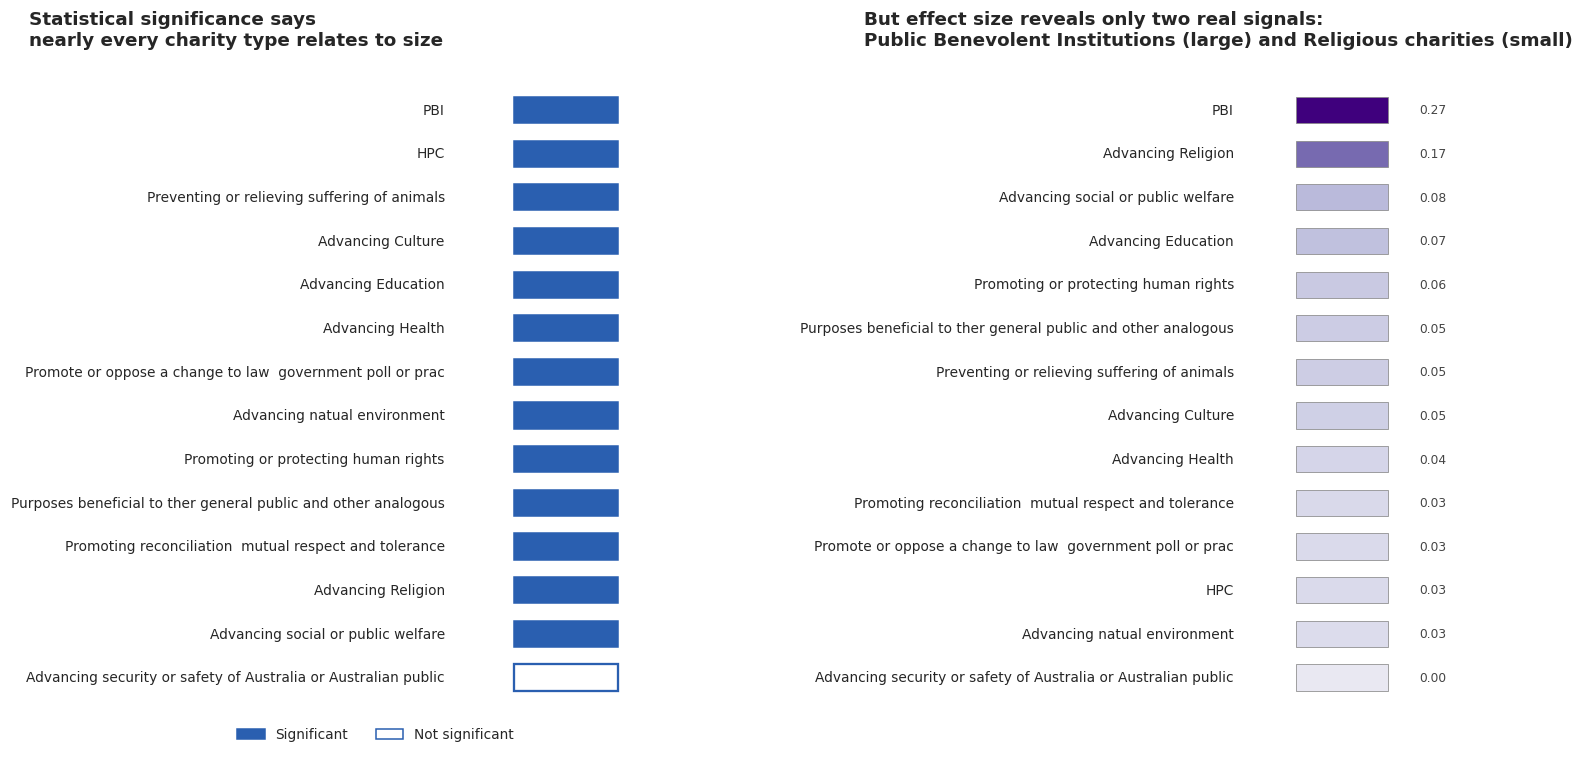

In [112]:
from matplotlib.patches import Rectangle, Patch

# --- Simulated stand-in for your real ACNC results ---
results_df = results_df.sort_values("cramers_v", ascending=False)
subtypes    = results_df["subtype"].tolist()
cramers_v   = results_df["cramers_v"].tolist()
significant = results_df["sig_after_bh"].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Binary grid of (significance)
ax1.set_title("Statistical significance says\nnearly every charity type relates to size",
              fontsize=12, fontweight="bold")
legend_elements = [
    Patch(facecolor="#2a5fb0", edgecolor="#2a5fb0", label="Significant"),
    Patch(facecolor="white", edgecolor="#2a5fb0", label="Not significant"),
]
ax1.legend(handles=legend_elements, loc="lower center",
           bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False, fontsize=9)

for i, (name, sig) in enumerate(zip(subtype_cols, significant)):
    y = len(subtypes) - i
    ax1.text(-0.1, y, name.replace("_", ' '), ha="right", va="center", fontsize=9)
    # filled if significant, empty (outline only) if not
    if sig:
        ax1.add_patch(Rectangle((0.3, y-0.3), 0.6, 0.6, facecolor="#2a5fb0", edgecolor="#2a5fb0"))
    else:
        ax1.add_patch(Rectangle((0.3, y-0.3), 0.6, 0.6, facecolor="white", edgecolor="#2a5fb0", linewidth=1.5))
ax1.set_xlim(-2.5, 1.5); ax1.set_ylim(0, len(subtypes)+1)
ax1.axis("off")

# Plot B: Effect-size heat-squares
ax2.set_title("But effect size reveals only two real signals:\nPublic Benevolent Institutions (large) and Religious charities (small)",
              fontsize=12, fontweight="bold")
cmap = plt.cm.Purples
vmax = max(cramers_v)
for i, (name, v) in enumerate(zip(subtypes, cramers_v)):
    y = len(subtypes) - i
    ax2.text(-0.1, y, name.replace("_", ' '), ha="right", va="center", fontsize=9)
    # colour intensity scales with effect size
    shade = cmap(0.15 + 0.85 * (v / vmax))
    ax2.add_patch(Rectangle((0.3, y-0.3), 0.6, 0.6, facecolor=shade, edgecolor="#888", linewidth=0.5))
    ax2.text(1.1, y, f"{v:.2f}", ha="left", va="center", fontsize=8, color="#444")
ax2.set_xlim(-2.5, 2.0); ax2.set_ylim(0, len(subtypes)+1)
ax2.axis("off")

plt.tight_layout()
plt.savefig("/tmp/significance_grid.png", dpi=120, bbox_inches="tight")
print("saved")

In [113]:
# # Permutation Test cross-check on subtypes that showed clear association
# # shuffle the labels
# var1_labels = df_new_filtered["Charity_Size"].values
# var2_labels = df_new_filtered[s].values

# # run the permutation loop
# num_permutations=10000
# permuted_stats = np.zeros(num_permutations)

# # set seed for reproducibility
# rng = np.random.default_rng(42)

# # copy one array and shuffle while keeping the other static
# shuffled_var1 = var1_labels.copy()

# for i in range(num_permutations):
#   # shuffle row labels under the null hypothesis
#   rng.shuffle(shuffled_var1)

#   # reconstruct permuted contingency table
#   perm_table = pd.crosstab(shuffled_var1, var2_labels).values

#   # calculate and store the test statistic for this permutation
#   # only pull the first returned value i.e. the statistic itself
#   permuted_stats[i] = scs.chi2_contingency(perm_table)[0]

# # calculate empirical p-value
# # this is the proportion of simulated statistics equal to or greater than
# # our original observed statistic

# p_value = (np.sum(permuted_stats >= res.statistic) + 1) / (num_permutations + 1)
# print("p-value:", p_value)

# print("--- Permutation Test Results ---")
# print(f"Observed Chi2 Statistic:     {res.statistic:.4f}")
# print(f"Empirical Permutation p-val: {p_value:.4f}")

## Which beneficiaries are most vs least supported nationally?




In [114]:
# Proportion of ALL charities serving each beneficiary
beneficiary_rates = df_new_filtered[benefactor_cols].mean().sort_values(ascending=False)
print("Most-served beneficiaries (share of charities nominating them):")
print((beneficiary_rates * 100).round(1))

Most-served beneficiaries (share of charities nominating them):
Youth                                  49.8
Adults                                 49.3
Families                               47.4
Aged_Persons                           44.6
Children                               43.5
General_Community_in_Australia         40.2
Females                                37.8
Males                                  35.6
Financially_Disadvantaged              33.2
Rural_Regional_Remote_Communities      30.9
Ethnic_Groups                          30.4
Early_Childhood                        30.1
People_with_Disabilities               27.4
Aboriginal_or_TSI                      26.6
People_at_risk_of_homelessness         19.8
Unemployed_Person                      19.3
People_with_Chronic_Illness            16.8
Victims_of_crime                       11.2
Other_Charities                        10.8
Veterans_or_their_families             10.8
Victims_of_Disasters                   10.0
Communities_

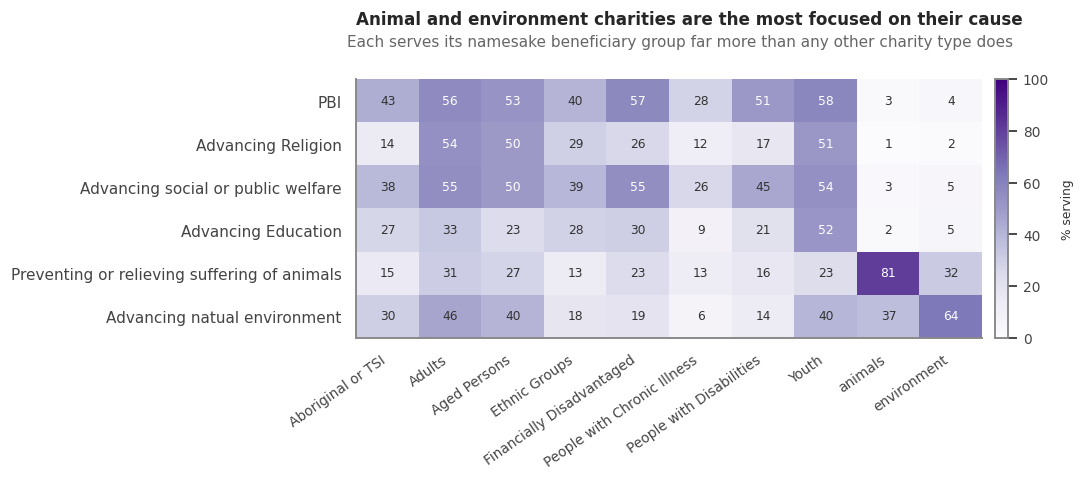

In [115]:
# For each subtype, the rate at which it serves each beneficiary
rate_matrix = []
for s in subtype_cols:
    sub_df = df_new_filtered[df_new_filtered[s] == 1]        # charities with this subtype
    rate_matrix.append(sub_df[benefactor_cols].mean().values)
rate_matrix = np.array(rate_matrix)                          # shape: subtypes x beneficiaries

# clean label lists (same order as the data they describe)
all_subtypes = [s.replace("_", " ") for s in subtype_cols]
all_benef    = [b.replace("_", " ") for b in benefactor_cols]

# ---- choose which rows (subtypes) to keep ----
keep_subtypes = ["PBI", "Advancing Religion", "Advancing social or public welfare",
                 "Advancing Education", "Preventing or relieving suffering of animals",
                 "Advancing natual environment"]
# find their positions; warn if any name doesn't match
row_idx = []
for s in keep_subtypes:
    if s in all_subtypes:
        row_idx.append(all_subtypes.index(s))
    else:
        print(f"WARNING: '{s}' not found in subtype labels — check spelling/underscores")

# ---- choose which columns (beneficiaries) vary most across subtypes ----
col_variance = rate_matrix.std(axis=0)
top_cols = np.argsort(col_variance)[::-1][:10]              # 10 most-varying beneficiaries
top_cols = sorted(top_cols)                                 # keep original order

# ---- subset the matrix to chosen rows AND columns ----
sub = rate_matrix[np.ix_(row_idx, top_cols)]
row_labels = [all_subtypes[i] for i in row_idx]
col_labels = [all_benef[j]    for j in top_cols]

# ---- plot the TRIMMED grid (note: uses `sub`, not rate_matrix) ----
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(sub * 100, cmap="Purples", aspect="auto", vmin=0, vmax=100)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10)

ax.set_title("Animal and environment charities are the most focused on their cause",
             fontsize=11, fontweight="bold", pad=36, loc="left")
fig.text(0.625, 0.89,
         "Each serves its namesake beneficiary group far more than any other charity type does",
         fontsize=10, color="#666", ha="center")
ax.grid(False)
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        val = sub[i, j] * 100
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=8,
                color="white" if val > 50 else "#333")

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("% serving", fontsize=8)

plt.tight_layout()
plt.savefig("/tmp/subtype_beneficiary_heatmap.png", bbox_inches="tight")
plt.show()

###

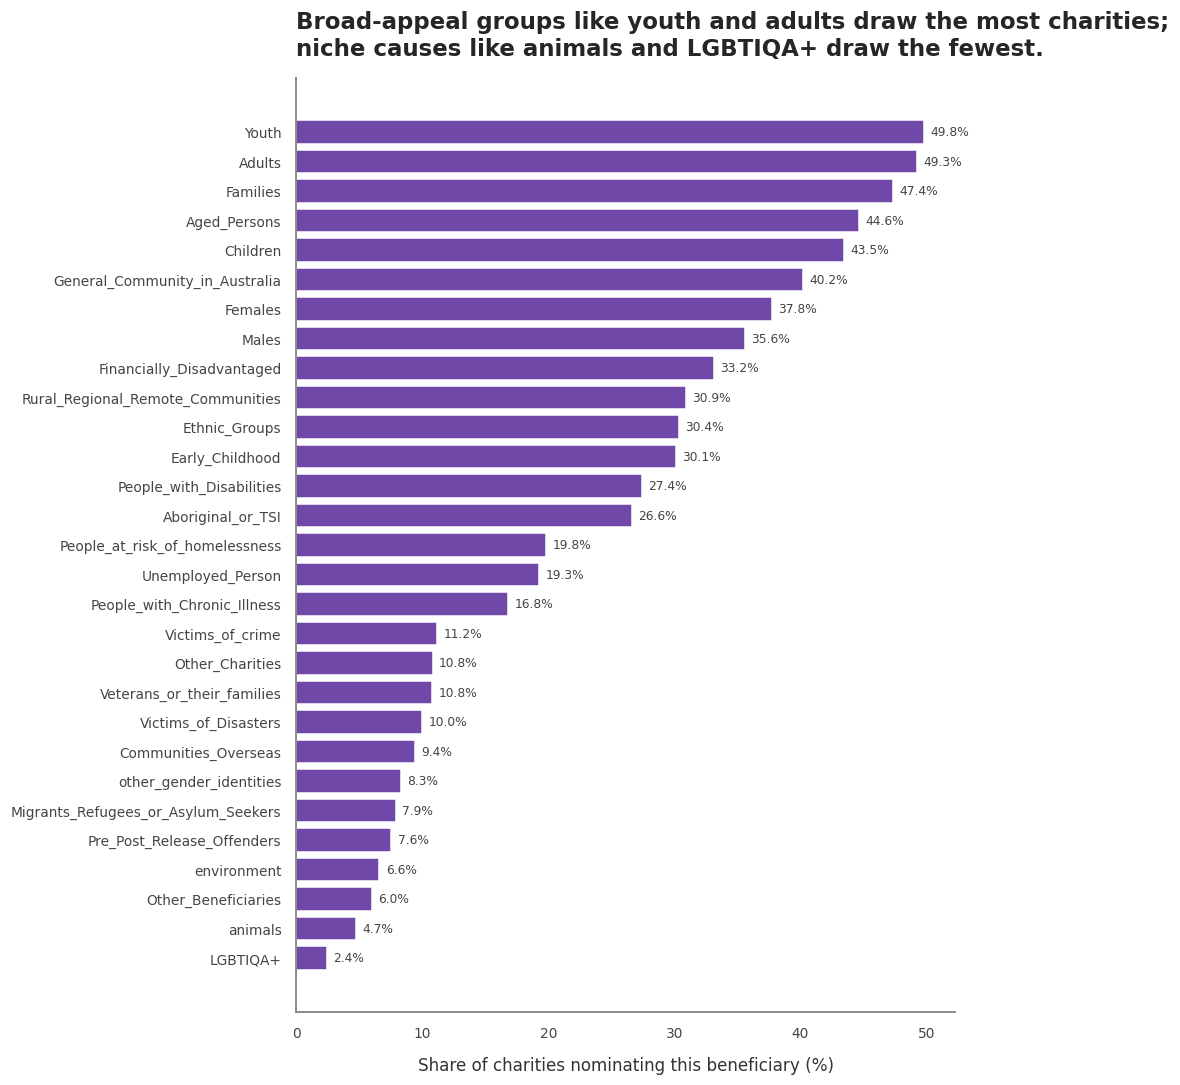

In [116]:
plot_data = (beneficiary_rates * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(plot_data.index, plot_data.values, color="#7048a8")

# takeaway title (bold) + descriptive subtitle
ax.set_title("Broad-appeal groups like youth and adults draw the most charities;\nniche causes like animals and LGBTIQA+ draw the fewest.",
             fontsize=15, fontweight="bold", loc="left", pad=15)
ax.set_xlabel("Share of charities nominating this beneficiary (%)", fontsize=11, labelpad=10)

# label each bar with its value
for i, v in enumerate(plot_data.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8, color="#444")

# --- remove gridlines and chart junk ---
ax.grid(False)                          # kill any gridlines
ax.spines["top"].set_visible(False)     # remove top border
ax.spines["right"].set_visible(False)   # remove right border
ax.tick_params(left=False)              # remove y-axis tick marks (keep labels)

plt.tight_layout()
plt.savefig("/tmp/beneficiary_ranking.png", dpi=120, bbox_inches="tight")
plt.show()